# SampleRateTap — block size vs. latency vs. quality

Real systems never move audio one sample at a time: ALSA periods, CoreAudio
buffers, USB transfers and DMA all deliver **blocks**. The block size you
choose interacts with an ASRC in three distinct ways:

1. **Latency floor.** The FIFO setpoint must exceed the block size (a pull
   of `B` frames needs `B` frames of backlog *at the moment it happens*, on
   top of the swing the block cadence itself causes). Bigger blocks ⇒
   bigger setpoint ⇒ more latency. The converter's own fixed cost (filter
   group delay, 0.5 ms) quickly becomes irrelevant next to this.
2. **Servo observability.** The clock servo's only sensor is FIFO
   occupancy, and occupancy changes in whole blocks. A 240-frame block
   quantizes the observable 240× more coarsely than sample-granular
   transfer — there is simply less information available about the clock
   offset, and the servo (by design) responds by staying in its
   medium-bandwidth *Track* stage rather than promoting to *Quiet*.
3. **Latency breathing.** In Track, the block-cadence beat is largely
   absorbed as slow FIFO-fill oscillation — latency wobble — with the
   remainder appearing as low-rate FM of the audio. How much of each, and
   whether the FM matters, is measured below.

This notebook measures all three with block sizes **32**, **64**, and
**240** (5 ms at 48 kHz) at a +200 ppm clock offset, and ends with the
latency comparison.


In [1]:
import ctypes, pathlib, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt

FS = 48000.0
REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
CAPI_DIR = REPO / "build" / "tools" / "capi"

def _find_dso():
    for name in ("libsrt_capi.so", "libsrt_capi.dylib", "srt_capi.dll"):
        hits = sorted(CAPI_DIR.rglob(name))
        if hits:
            return hits[0]
    return None

def _run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout)
        print(r.stderr, file=sys.stderr)
        raise RuntimeError("command failed: " + " ".join(cmd))

DSO = _find_dso()
if DSO is None:
    _run(["cmake", "-B", str(REPO / "build"), "-S", str(REPO),
          "-DCMAKE_BUILD_TYPE=Release", "-DSRT_BUILD_CAPI=ON"])
    _run(["cmake", "--build", str(REPO / "build"), "--target", "srt_capi",
          "--config", "Release", "-j"])
    DSO = _find_dso()
assert DSO is not None, "libsrt_capi not found after build"

_lib = ctypes.CDLL(str(DSO))
_lib.srt_create.restype = ctypes.c_void_p
_lib.srt_create.argtypes = [ctypes.c_double, ctypes.c_size_t, ctypes.c_size_t, ctypes.c_int]
_lib.srt_destroy.argtypes = [ctypes.c_void_p]
_FLOATP = ctypes.POINTER(ctypes.c_float)
_lib.srt_push.argtypes = [ctypes.c_void_p, _FLOATP, ctypes.c_size_t]
_lib.srt_push.restype = ctypes.c_size_t
_lib.srt_pull.argtypes = [ctypes.c_void_p, _FLOATP, ctypes.c_size_t]
_lib.srt_pull.restype = ctypes.c_size_t
_lib.srt_status.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double)]
_lib.srt_designed_latency_seconds.argtypes = [ctypes.c_void_p]
_lib.srt_designed_latency_seconds.restype = ctypes.c_double

STATES = {0: "Filling", 1: "Acquiring", 2: "Locked"}

class Asrc:
    def __init__(self, fs=FS, channels=1, target_latency=0, preset=1):
        self._h = _lib.srt_create(fs, channels, target_latency, preset)
        assert self._h, "srt_create failed"
    def push(self, x):
        x = np.ascontiguousarray(x, dtype=np.float32)
        return _lib.srt_push(self._h, x.ctypes.data_as(_FLOATP), len(x))
    def pull(self, out):
        return _lib.srt_pull(self._h, out.ctypes.data_as(_FLOATP), len(out))
    def status(self):
        s = (ctypes.c_double * 6)()
        _lib.srt_status(self._h, s)
        return dict(state=int(s[0]), ppm=s[1], fill=s[2],
                    underruns=int(s[3]), overruns=int(s[4]), resyncs=int(s[5]))
    @property
    def designed_latency(self):
        return _lib.srt_designed_latency_seconds(self._h)
    def __del__(self):
        if getattr(self, "_h", None):
            _lib.srt_destroy(self._h)

def run_two_clock(asrc, seconds, eps, input_signal, chunk):
    """Push/pull in `chunk`-frame blocks; telemetry logged every pull."""
    fs_in, fs_out = FS * (1.0 + eps), FS
    n_out = int(seconds * fs_out)
    out = np.zeros(n_out + chunk, dtype=np.float32)
    buf = np.zeros(chunk, dtype=np.float32)
    log = {k: [] for k in ("t", "state", "ppm", "fill", "underruns")}
    t_in = t_out = 0.0
    i_in = i_out = 0
    while i_out < n_out:
        if t_in <= t_out:
            asrc.push(input_signal[i_in:i_in + chunk])
            i_in += chunk
            t_in += chunk / fs_in
        else:
            asrc.pull(buf)
            out[i_out:i_out + chunk] = buf
            i_out += chunk
            t_out += chunk / fs_out
            s = asrc.status()
            log["t"].append(t_out)
            for k in ("state", "ppm", "fill", "underruns"):
                log[k].append(s[k])
    return out[:n_out], {k: np.asarray(v) for k, v in log.items()}

def sine(n, freq, amp=0.5):
    return (amp * np.sin(2 * np.pi * freq / FS * np.arange(n))).astype(np.float32)

def spectrum_db(x):
    w = np.kaiser(len(x), 24.0)
    X = np.fft.rfft(x * w)
    f = np.fft.rfftfreq(len(x), 1 / FS)
    return f, 20 * np.log10(np.maximum(np.abs(X) / (np.sum(w) / 2), 1e-12))

def fit_sine_windowed(x, nu, win=2048):
    n = (len(x) // win) * win
    resid = np.empty(n)
    amps = []
    ph = 2 * np.pi * nu * np.arange(n)
    for k in range(n // win):
        sl = slice(k * win, (k + 1) * win)
        A = np.column_stack([np.sin(ph[sl]), np.cos(ph[sl]), np.ones(win)])
        c, *_ = np.linalg.lstsq(A, x[sl].astype(np.float64), rcond=None)
        resid[sl] = x[sl] - A @ c
        amps.append(np.hypot(c[0], c[1]))
    return float(np.mean(amps)), resid

def snr_db(x, nu, win=2048):
    amp, resid = fit_sine_windowed(x, nu, win)
    return 20 * np.log10(amp / np.sqrt(2) / np.std(resid)), resid

EPS = 200e-6
print(f"loaded {DSO.name}")

loaded libsrt_capi.so


## The three configurations

The FIFO setpoint is sized as `2 × block` (with the library default 48 as a
floor): one block of drainable backlog for the pull that is about to happen,
plus headroom for the block-cadence swing. That sizing rule is the latency
story in miniature — it makes total latency essentially proportional to
block size:

> **total latency ≈ 2·B / fs + 0.5 ms (filter group delay)**

The converter contributes a fixed 0.5 ms; everything else is the block
size's doing.


In [2]:
BLOCKS = [32, 64, 240]
COLORS = {32: "tab:blue", 64: "tab:orange", 240: "tab:red"}
configs = {}
for B in BLOCKS:
    target = max(48, 2 * B)
    a = Asrc(target_latency=target)
    configs[B] = dict(target=target, designed_ms=a.designed_latency * 1e3)
    del a
    print(f"block {B:4d} frames ({B/FS*1e3:5.2f} ms)  ->  setpoint {target:3d} frames, "
          f"designed latency {configs[B]['designed_ms']:5.2f} ms")

block   32 frames ( 0.67 ms)  ->  setpoint  64 frames, designed latency  1.83 ms
block   64 frames ( 1.33 ms)  ->  setpoint 128 frames, designed latency  3.17 ms
block  240 frames ( 5.00 ms)  ->  setpoint 480 frames, designed latency 10.50 ms


## Lock acquisition and steady-state fill

30 s of a 997 Hz tone at +200 ppm through each configuration. Left: the rate
estimate converging. Right: the steady-state FIFO fill relative to its
setpoint — **latency breathing**, the block-cadence beat absorbed as slow
occupancy wobble instead of audible pitch wobble. Its amplitude scales with
the block size.


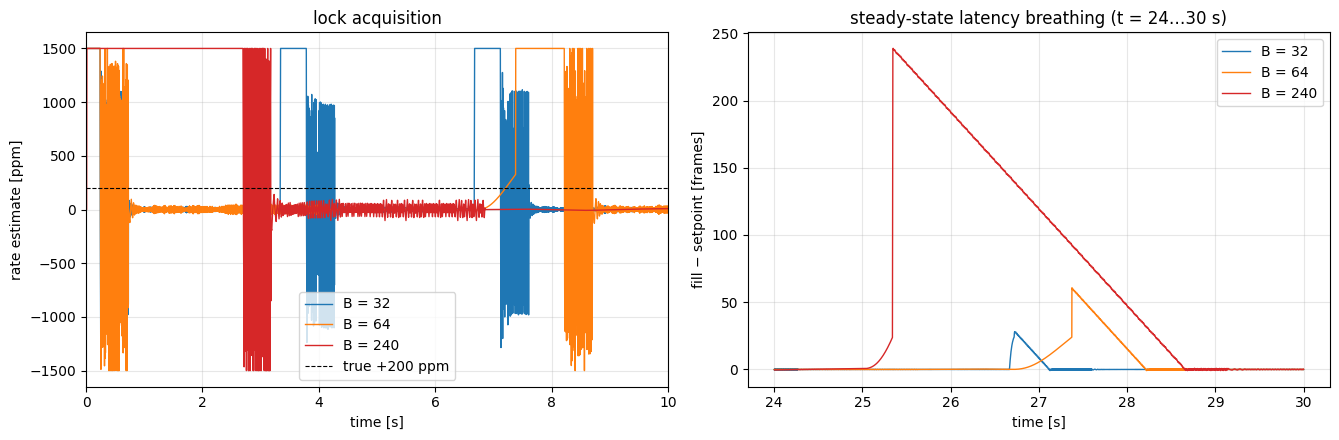

B=  32: locked at  0.73 s,  final ppm  -20.06,  steady fill peak-to-peak   29.0 frames (0.60 ms)
B=  64: locked at  0.73 s,  final ppm   +4.09,  steady fill peak-to-peak   61.6 frames (1.28 ms)
B= 240: locked at  3.18 s,  final ppm  +53.63,  steady fill peak-to-peak  239.6 frames (4.99 ms)


In [3]:
SIM_S = 30.0
runs = {}
for B in BLOCKS:
    asrc = Asrc(target_latency=configs[B]["target"])
    n_in = int(SIM_S * FS * (1 + EPS)) + 2 * B
    y, log = run_two_clock(asrc, SIM_S, EPS, sine(n_in, 997.0), chunk=B)
    runs[B] = dict(y=y, log=log, final=asrc.status())
    assert runs[B]["final"]["underruns"] == 0, f"underrun at block {B}"

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.5))
for B in BLOCKS:
    log = runs[B]["log"]
    ax[0].plot(log["t"], log["ppm"], lw=1.0, color=COLORS[B], label=f"B = {B}")
    sl = log["t"] >= 24.0
    ax[0].set(xlim=(0, 10))
    ax[1].plot(log["t"][sl], log["fill"][sl] - configs[B]["target"], lw=1.0,
               color=COLORS[B], label=f"B = {B}")
ax[0].axhline(EPS * 1e6, color="k", ls="--", lw=0.8, label="true +200 ppm")
ax[0].set(xlabel="time [s]", ylabel="rate estimate [ppm]", title="lock acquisition")
ax[1].set(xlabel="time [s]", ylabel="fill − setpoint [frames]",
          title="steady-state latency breathing (t = 24…30 s)")
for a in ax:
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for B in BLOCKS:
    log, fin = runs[B]["log"], runs[B]["final"]
    locked_at = log["t"][np.argmax(log["state"] == 2)] if (log["state"] == 2).any() else np.nan
    sl = log["t"] >= 24.0
    breathe = np.ptp(log["fill"][sl])
    print(f"B={B:4d}: locked at {locked_at:5.2f} s,  final ppm {fin['ppm']:+7.2f},  "
          f"steady fill peak-to-peak {breathe:6.1f} frames ({breathe/FS*1e3:.2f} ms)")

## Audio quality vs. block size

With block transfer the servo (deliberately) stays in its *Track* stage,
and the block-quantization noise it cannot remove frequency-modulates the
audio at low rates. A raw "SNR" number is the wrong lens for this artifact
— cent-scale FM annihilates a sine fit long before it is audible (FM
detection thresholds for tones sit around 5–8 cents at these modulation
rates) — so we split the measurement at ~60 Hz: below it, **pitch
modulation in cents**; above it, the **wideband floor** via the standard
phase-noise identity.

The instrument is calibrated first on a synthetic signal with known FM and
known noise. (This cell earned its keep: three earlier formulations of the
split each leaked modulation into the noise figure, and the calibration
caught every one.)


In [4]:
nu_out = 997.0 * (1 + EPS) / FS
f0_out = nu_out * FS

def analytic(x):
    X = np.fft.fft(x.astype(np.float64))
    n = len(x)
    h = np.zeros(n)
    h[0] = 1.0
    if n % 2 == 0:
        h[n // 2] = 1.0
    h[1:(n + 1) // 2] = 2.0
    return np.fft.ifft(X * h)

def lowpass_fft(x, f_pass=60.0, f_stop=100.0):
    """Flat-passband lowpass (FFT brickwall with raised-cosine transition).
    A boxcar will not do here: its passband droop leaves a percent-level
    copy of the modulation in the highpassed remainder, which then bounds
    the measurable floor (that bug cost three iterations of this cell)."""
    trend = np.polyval(np.polyfit(np.arange(len(x)), x, 1), np.arange(len(x)))
    X = np.fft.rfft(x - trend)
    f = np.fft.rfftfreq(len(x), 1 / FS)
    w = np.clip((f_stop - f) / (f_stop - f_pass), 0.0, 1.0)
    w = 0.5 - 0.5 * np.cos(np.pi * w)
    return trend + np.fft.irfft(X * w, len(x))

def decompose(x, guard_s=0.5):
    """Split a near-sinusoid into pitch modulation below ~60 Hz (in cents)
    and carrier-relative noise above it (the wideband floor). Works in the
    demodulated domain: for small deviations the wideband SNR is
    1 / (<a_hp^2> + <theta_hp^2>), the standard phase-noise identity.
    (Reconstruct-and-subtract in the signal domain fails subtly: sub-split
    phase errors multiply the carrier and land at the carrier frequency.)"""
    n = len(x)
    t = np.arange(n)
    z = analytic(x)
    theta = np.unwrap(np.angle(z)) - 2 * np.pi * nu_out * t
    theta_s = lowpass_fft(theta)
    amp = np.abs(z)
    amp_s = lowpass_fft(amp)
    g = int(guard_s * FS)
    sl = slice(g, n - g)
    theta_hp = (theta - theta_s)[sl]
    a_hp = ((amp - amp_s) / np.median(amp_s))[sl]
    fdev = np.diff(theta_s[sl]) * FS / (2 * np.pi)
    cents = 1200.0 * np.log2(1.0 + fdev / f0_out)
    cents -= np.mean(cents)  # static tuning offset is not modulation
    return dict(cents=cents,
                cents_rms=float(np.std(cents)),
                cents_peak=float(np.percentile(np.abs(cents), 99.9)),
                snr_wide=float(-10 * np.log10(np.mean(a_hp**2) + np.mean(theta_hp**2))))

# --- calibration: 10 Hz FM at exactly 1 cent peak, noise at -120 dB ------
t = np.arange(int(10 * FS))
beta_rad = (2 ** (1 / 1200) - 1) * f0_out / 10.0  # 1-cent peak deviation at 10 Hz
cal = (0.5 * np.sin(2 * np.pi * nu_out * t
                    + beta_rad * np.sin(2 * np.pi * 10.0 * t / FS))
       + 10 ** (-120 / 20) * np.random.default_rng(7).standard_normal(len(t))
       ).astype(np.float32)
m = decompose(cal)
print(f"calibration: peak {m['cents_peak']:.3f} cents (true 1.000), "
      f"rms {m['cents_rms']:.3f} (true 0.707), wideband {m['snr_wide']:.1f} dB "
      f"(true ~111)")
assert 0.9 < m["cents_peak"] < 1.1 and m["snr_wide"] > 105


calibration: peak 1.000 cents (true 1.000), rms 0.707 (true 0.707), wideband 111.0 dB (true ~111)


The instrument reads a known 1-cent / 10 Hz FM and a known noise floor
correctly. Now the three block sizes:


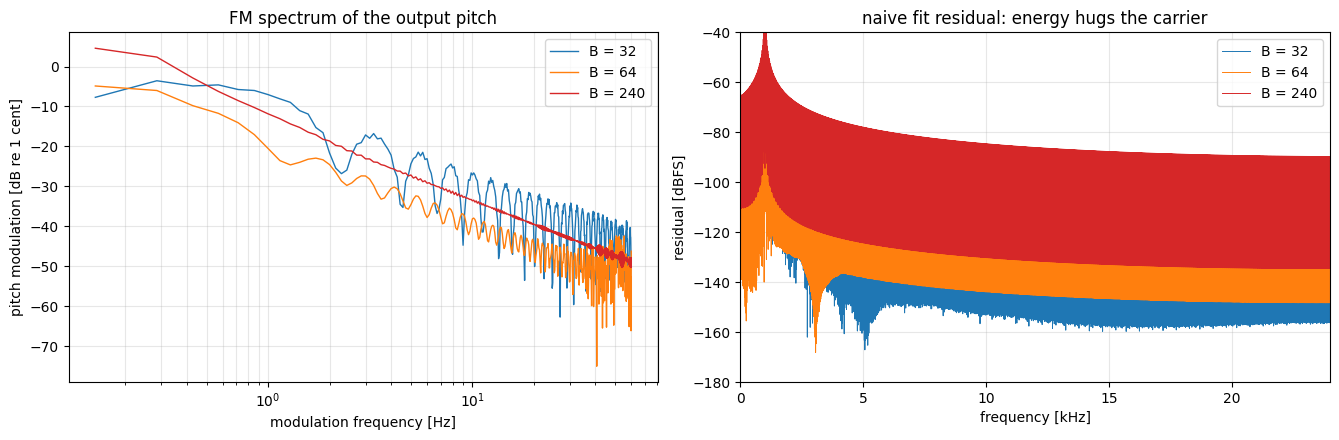

    B  FM rms [cents]  FM peak [cents]  wideband SNR [dB]
   32           0.868            2.387               60.9
   64           0.842            2.354               58.2
  240           1.337            4.219               53.1


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.5))
metrics = {}
for B in BLOCKS:
    steady = runs[B]["y"][int((SIM_S - 8.0) * FS):]
    m = decompose(steady)
    metrics[B] = m
    # FM spectrum: where in modulation-frequency the pitch wobble lives
    c = m["cents"]
    w = np.kaiser(len(c), 12.0)
    C = np.abs(np.fft.rfft(c * w)) / (np.sum(w) / 2)
    fm_f = np.fft.rfftfreq(len(c), 1 / FS)
    sl = (fm_f > 0.05) & (fm_f < 60)
    ax[0].semilogx(fm_f[sl], 20 * np.log10(np.maximum(C[sl], 1e-6)),
                   lw=1.0, color=COLORS[B], label=f"B = {B}")
    _, resid = snr_db(steady, nu_out)  # naive fit for the spectrum view
    f, S = spectrum_db(resid)
    ax[1].plot(f / 1e3, S, lw=0.7, color=COLORS[B], label=f"B = {B}")
ax[0].set(xlabel="modulation frequency [Hz]", ylabel="pitch modulation [dB re 1 cent]",
          title="FM spectrum of the output pitch")
ax[1].set(xlabel="frequency [kHz]", ylabel="residual [dBFS]", xlim=(0, 24),
          ylim=(-180, -40), title="naive fit residual: energy hugs the carrier")
for a in ax:
    a.legend(); a.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print(f"{'B':>5} {'FM rms [cents]':>15} {'FM peak [cents]':>16} {'wideband SNR [dB]':>18}")
for B in BLOCKS:
    m = metrics[B]
    print(f"{B:5d} {m['cents_rms']:15.3f} {m['cents_peak']:16.3f} {m['snr_wide']:18.1f}")

for B in BLOCKS:
    # Documented behavior as of this measurement: FM peaks stay below the
    # ~5-8 cent audibility region (B=240 gets closest) and the wideband
    # floor stays above 50 dB. These pin behavior, not aspiration.
    assert metrics[B]["cents_peak"] < 5.0, f"FM at B={B} reached audibility"
    assert metrics[B]["snr_wide"] > 45, f"wideband floor degraded at B={B}"


## Latency, measured — including the breathing

Arithmetic says latency = setpoint + group delay. But with block transfer
the *actual* FIFO fill oscillates, so instantaneous latency is a band, not
a number. We send an **impulse every 350 ms** through each running
converter (+200 ppm still applied) and measure each one's actual transit
time. Two things to expect: the band's width is the breathing, and its
*mean* sits roughly half a block below the designed figure — the designed
number counts the setpoint, while the backlog at the instant a pull
happens averages about B/2 lower in the push/pull cadence.


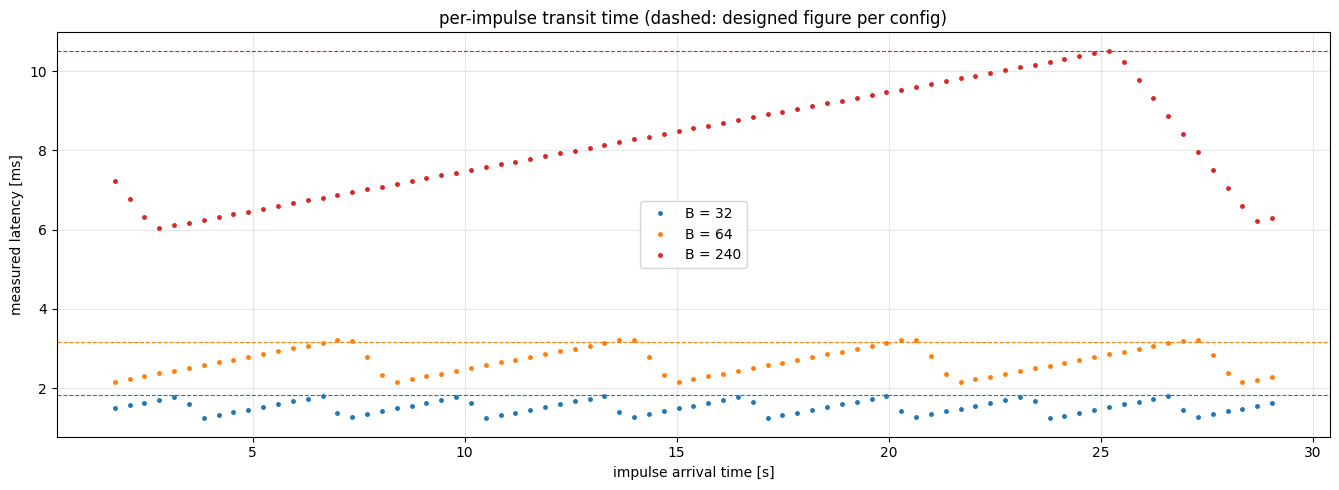

    B  designed    mean     min     max    p-p  [ms]
   32      1.83    1.52    1.24    1.81   0.57
   64      3.17    2.68    2.15    3.22   1.07
  240     10.50    8.19    6.04   10.52   4.48


In [6]:
IMP_EVERY = int(0.35 * FS)
imp_results = {}
for B in BLOCKS:
    asrc = Asrc(target_latency=configs[B]["target"])
    n_in = int(SIM_S * FS * (1 + EPS)) + 2 * B
    x = np.zeros(n_in, dtype=np.float32)
    imp_idx = np.arange(5 * IMP_EVERY, n_in - 2 * IMP_EVERY, IMP_EVERY)
    x[imp_idx] = 0.9
    y, _ = run_two_clock(asrc, SIM_S, EPS, x, chunk=B)
    assert asrc.status()["underruns"] == 0
    delays = []
    times = []
    for i in imp_idx:
        t_arrive = i / (FS * (1 + EPS))          # when the impulse entered
        j0 = int(t_arrive * FS)
        w = y[j0: j0 + int(0.03 * FS)]           # search 30 ms forward
        if len(w) and np.max(np.abs(w)) > 0.3:
            j = j0 + int(np.argmax(np.abs(w)))
            delays.append((j / FS - t_arrive) * 1e3)
            times.append(t_arrive)
    imp_results[B] = (np.asarray(times), np.asarray(delays))

fig, ax = plt.subplots(figsize=(13.5, 5))
for B in BLOCKS:
    t, d = imp_results[B]
    ax.plot(t, d, ".", ms=5, color=COLORS[B], label=f"B = {B}")
    ax.axhline(configs[B]["designed_ms"], color=COLORS[B], ls="--", lw=0.8)
ax.set(xlabel="impulse arrival time [s]", ylabel="measured latency [ms]",
       title="per-impulse transit time (dashed: designed figure per config)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'B':>5} {'designed':>9} {'mean':>7} {'min':>7} {'max':>7} {'p-p':>6}  [ms]")
for B in BLOCKS:
    _, d = imp_results[B]
    print(f"{B:5d} {configs[B]['designed_ms']:9.2f} {d.mean():7.2f} "
          f"{d.min():7.2f} {d.max():7.2f} {np.ptp(d):6.2f}")

## The latency comparison, decomposed

Stacking the pieces makes the economics plain: the polyphase filter costs a
fixed 0.5 ms regardless of block size, while the FIFO setpoint — forced by
the block cadence — dominates and scales linearly. The whiskers show the
measured min–max transit band from the impulse experiment above.


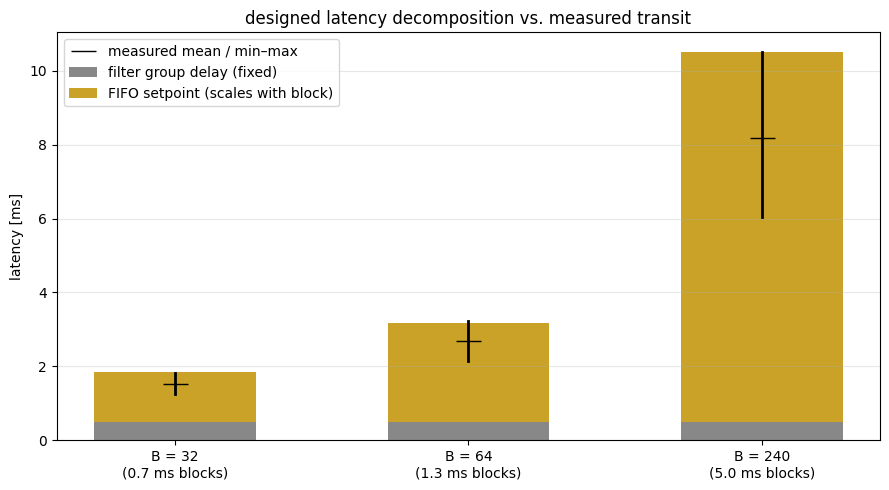

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
xs = np.arange(len(BLOCKS))
gd_ms = 24 / FS * 1e3  # balanced-preset group delay
set_ms = [configs[B]["target"] / FS * 1e3 for B in BLOCKS]
ax.bar(xs, [gd_ms] * len(BLOCKS), 0.55, label="filter group delay (fixed)",
       color="#888")
ax.bar(xs, set_ms, 0.55, bottom=gd_ms, label="FIFO setpoint (scales with block)",
       color="#c9a227")
for k, B in enumerate(BLOCKS):
    _, d = imp_results[B]
    ax.plot([k, k], [d.min(), d.max()], color="k", lw=2)
    ax.plot(k, d.mean(), "k_", ms=18, label="measured mean / min–max" if k == 0 else None)
ax.set(xticks=xs, xticklabels=[f"B = {B}\n({B/FS*1e3:.1f} ms blocks)" for B in BLOCKS],
       ylabel="latency [ms]", title="designed latency decomposition vs. measured transit")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Summary

| | B = 32 | B = 64 | B = 240 (5 ms) |
|---|---|---|---|
| FIFO setpoint | 64 frames | 128 frames | 480 frames |
| Designed latency | 1.83 ms | 3.17 ms | 10.50 ms |
| Measured latency band | ~0.6 ms wide | ~1.1 ms wide | ~4.5 ms wide |
| Pitch modulation (rms / peak) | ≈0.9 / 2.4 cents | ≈0.8 / 2.4 cents | ≈1.3 / 4.2 cents |
| Wideband floor | ≈61 dB | ≈58 dB | ≈53 dB |
| Underruns over 30 s | 0 | 0 | 0 |

**The latency comparison.** The converter's own contribution is a fixed
0.5 ms of filter group delay; everything else is FIFO setpoint that the
block cadence forces (≈ 2·B), plus breathing of roughly a block around it.
Going from 32-frame to 5 ms blocks costs ~9 ms of designed latency and
turns a ~0.6 ms latency band into a ~4.5 ms one. **Block size is the
latency budget; the ASRC is a rounding error.**

**The quality comparison, honestly.** Coarse-block operation is *not*
transparent: the Track stage converts block quantization into cent-scale
low-rate FM (peaking at ~4 cents at B = 240 — below, but within sight of,
audibility) over a 53–61 dB wideband floor. That is far better than the
naive FIFO's clicks (~30 dB and unambiguously audible), and entirely
adequate for monitoring, intercom, conferencing and similar paths — but it
is a different regime from the ~126 dB the same library achieves with
sample-granular transfer (see `asrc_demo.ipynb`). If transparency matters,
feed the converter fine-grained even if your device callback is large:
push in sub-blocks.

Configuration guidance: `targetLatencyFrames ≈ 2 × block`; prefer the
smallest block your scheduling jitter allows; and treat large-block
operation as a serviceable fallback, not the design point.
